# ⚙️ Sistemas Operacionais

`Sistemas/Redes` · **Engenharia da Computação** · `Python 3`

> **Processos, threads, escalonamento, sincronização, memória e arquivos.**

Núcleo do sistema operacional: escalonamento (FCFS/SJF/RR), sincronização com locks, substituição de páginas (FIFO/LRU) e concorrência — simulados em Python.



## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 PROCESSOS & THREADS

**Ideia:** Entender execução concorrente, estados e como processos e threads usam recursos do sistema.

- Processo: programa em execução com recursos próprios
- Estados: novo, pronto, executando, espera e terminado
- PCB: PID + registradores + estado + contador de programa
- Thread: unidade de execução dentro de um processo
- Compartilhamento: threads dividem código, dados e arquivos
- Pilha: cada thread possui sua própria pilha
- Troca de contexto: salva estado atual e restaura o próximo
- Processo × thread: processo isola memória; thread é mais leve

> 💡 **Dica:** Processo tem espaço de endereçamento próprio; threads do mesmo processo compartilham memória e recursos.

### 🟢 ESCALONAMENTO & SINCRONIZAÇÃO

**Ideia:** Distribuir CPU entre tarefas e proteger recursos compartilhados contra acessos incorretos.

- Objetivo: melhorar utilização da CPU e tempo de resposta
- FCFS: primeiro a chegar, primeiro a ser atendido
- SJF: menor trabalho primeiro
- Prioridade: maior prioridade executa antes
- Round Robin: cada processo recebe um quantum
- Preemptivo: SO pode interromper a execução
- Seção crítica: trecho que acessa recurso compartilhado
- Sincronização: mutex e semáforos evitam race conditions
- Deadlock: exclusão mútua + posse/espera + não preempção + ciclo

> 💡 **Dica:** Round Robin é clássico em time-sharing. Quantum muito pequeno aumenta o overhead de troca de contexto.

### 🟢 MEMÓRIA & MEMÓRIA VIRTUAL

**Ideia:** Mapear endereços e usar paginação para ampliar a memória disponível ao processo.

- Endereço lógico: gerado pelo processo
- Endereço físico: posição real na RAM
- Paginação: memória lógica em páginas e física em quadros
- Tabela de páginas: mapeia página lógica → quadro físico
- Fragmentação interna: sobra dentro de um quadro
- Memória virtual: usa disco para ampliar a memória aparente
- Page fault: página necessária não está na RAM
- Substituição: FIFO, LRU e Ótimo (conceitual)
- Thrashing: excesso de page faults e pouca execução útil

> 💡 **Dica:** Muitos page faults seguidos podem indicar thrashing: o sistema passa mais tempo trocando páginas do que executando.

### 🟢 ARQUIVOS, E/S & PROTEÇÃO

**Ideia:** Organizar armazenamento, controlar dispositivos e proteger o acesso aos recursos do sistema.

- Arquivo: conjunto ordenado de bytes com nome e metadados
- Diretórios: organizam arquivos de forma hierárquica
- Operações: abrir, ler, escrever, fechar, criar e deletar
- E/S: pode usar interrupção, polling ou DMA
- DMA: transferência direta entre dispositivo e memória
- Proteção: usuários, permissões e modos de acesso
- Modo usuário: restrito; modo kernel: privilegiado
- Syscall: interface controlada entre aplicação e kernel
- Kernel: gerencia recursos com segurança e eficiência

> 💡 **Dica:** Syscall é a ponte controlada entre programas em modo usuário e os serviços privilegiados oferecidos pelo kernel.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Sistemas_Operacionais.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'PROCESSOS &amp;<br/>THREADS',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'processos',
        'idea': 'Entender execução concorrente, estados e como processos e threads usam recursos do sistema.',
        'formulas': [
            '<b>Processo:</b> programa em execução com recursos próprios',
            '<b>Estados:</b> novo, pronto, executando, espera e terminado',
            '<b>PCB:</b> PID + registradores + estado + contador de programa',
            '<b>Thread:</b> unidade de execução dentro de um processo',
            '<b>Compartilhamento:</b> threads dividem código, dados e arquivos',
            '<b>Pilha:</b> cada thread possui sua própria pilha',
            '<b>Troca de contexto:</b> salva estado atual e restaura o próximo',
            '<b>Processo × thread:</b> processo isola memória; thread é mais leve',
        ],
        'tip': 'Processo tem espaço de endereçamento próprio; threads do mesmo processo compartilham memória e recursos.',
    },
    {
        'title': 'ESCALONAMENTO &amp;<br/>SINCRONIZAÇÃO',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'escalonamento',
        'idea': 'Distribuir CPU entre tarefas e proteger recursos compartilhados contra acessos incorretos.',
        'formulas': [
            '<b>Objetivo:</b> melhorar utilização da CPU e tempo de resposta',
            '<b>FCFS:</b> primeiro a chegar, primeiro a ser atendido',
            '<b>SJF:</b> menor trabalho primeiro',
            '<b>Prioridade:</b> maior prioridade executa antes',
            '<b>Round Robin:</b> cada processo recebe um quantum',
            '<b>Preemptivo:</b> SO pode interromper a execução',
            '<b>Seção crítica:</b> trecho que acessa recurso compartilhado',
            '<b>Sincronização:</b> mutex e semáforos evitam race conditions',
            '<b>Deadlock:</b> exclusão mútua + posse/espera + não preempção + ciclo',
        ],
        'tip': 'Round Robin é clássico em time-sharing. Quantum muito pequeno aumenta o overhead de troca de contexto.',
    },
    {
        'title': 'MEMÓRIA &amp;<br/>MEMÓRIA VIRTUAL',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'memoria',
        'idea': 'Mapear endereços e usar paginação para ampliar a memória disponível ao processo.',
        'formulas': [
            '<b>Endereço lógico:</b> gerado pelo processo',
            '<b>Endereço físico:</b> posição real na RAM',
            '<b>Paginação:</b> memória lógica em páginas e física em quadros',
            '<b>Tabela de páginas:</b> mapeia página lógica → quadro físico',
            '<b>Fragmentação interna:</b> sobra dentro de um quadro',
            '<b>Memória virtual:</b> usa disco para ampliar a memória aparente',
            '<b>Page fault:</b> página necessária não está na RAM',
            '<b>Substituição:</b> FIFO, LRU e Ótimo (conceitual)',
            '<b>Thrashing:</b> excesso de page faults e pouca execução útil',
        ],
        'tip': 'Muitos page faults seguidos podem indicar thrashing: o sistema passa mais tempo trocando páginas do que executando.',
    },
    {
        'title': 'ARQUIVOS, E/S<br/>&amp; PROTEÇÃO',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'arquivos',
        'idea': 'Organizar armazenamento, controlar dispositivos e proteger o acesso aos recursos do sistema.',
        'formulas': [
            '<b>Arquivo:</b> conjunto ordenado de bytes com nome e metadados',
            '<b>Diretórios:</b> organizam arquivos de forma hierárquica',
            '<b>Operações:</b> abrir, ler, escrever, fechar, criar e deletar',
            '<b>E/S:</b> pode usar interrupção, polling ou DMA',
            '<b>DMA:</b> transferência direta entre dispositivo e memória',
            '<b>Proteção:</b> usuários, permissões e modos de acesso',
            '<b>Modo usuário:</b> restrito; <b>modo kernel:</b> privilegiado',
            '<b>Syscall:</b> interface controlada entre aplicação e kernel',
            '<b>Kernel:</b> gerencia recursos com segurança e eficiência',
        ],
        'tip': 'Syscall é a ponte controlada entre programas em modo usuário e os serviços privilegiados oferecidos pelo kernel.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title', fontName='DVCond-Bold', fontSize=17.2, leading=18.6,
    textColor=WHITE, alignment=1
)
STYLE_IDEA = ParagraphStyle(
    'idea', fontName='DVCond-Oblique', fontSize=12.6, leading=15.6,
    textColor=MUTED
)
STYLE_TIP = ParagraphStyle(
    'tip', fontName='DVCond', fontSize=11.7, leading=14.7,
    textColor=INK
)


def arrow(c, x1, y1, x2, y2, color, width=1.2, head=4.5):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2-y1, x2-x1)
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + head*math.cos(ang+delta), y2 + head*math.sin(ang+delta))


def small_box(c, x, y, w, h, color, label, fs=8.0):
    c.setStrokeColor(color)
    c.setFillColor(HexColor('#F8FAFD'))
    c.setLineWidth(1.1)
    c.roundRect(x, y, w, h, 3, fill=1, stroke=1)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', fs)
    c.drawCentredString(x+w/2, y+h/2-3, label)


def diagram_processos(c, ox, oy, dw, dh, color):
    py = oy + dh*0.58
    small_box(c, ox+dw*0.02, py, 48, 26, color, 'Processo')
    arrow(c, ox+dw*0.28, py+13, ox+dw*0.42, py+13, color, 1.0, 4)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 8)
    c.drawCentredString(ox+dw*0.35, py+23, 'cria')
    # threads
    for i in range(3):
        x = ox + dw*(0.56 + 0.13*i)
        path = c.beginPath()
        path.moveTo(x, py+2)
        path.curveTo(x-5, py+8, x+5, py+13, x, py+19)
        path.curveTo(x-5, py+23, x+5, py+28, x, py+34)
        c.setStrokeColor(color)
        c.setLineWidth(1.0)
        c.drawPath(path, stroke=1, fill=0)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 7.5)
    c.drawCentredString(ox+dw*0.73, py+39, 'Threads T1 T2 T3')
    # states
    y = oy + dh*0.20
    xs = [ox+dw*0.08, ox+dw*0.34, ox+dw*0.60, ox+dw*0.84]
    labs = ['Novo', 'Pronto', 'Exec.', 'Espera']
    for x, lab in zip(xs, labs):
        c.setStrokeColor(color)
        c.setLineWidth(1.0)
        c.circle(x, y, 13, stroke=1, fill=0)
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 7.2)
        c.drawCentredString(x, y-2.5, lab)
    for a,b in zip(xs[:-1], xs[1:]):
        arrow(c, a+14, y, b-14, y, color, 0.9, 3.6)
    arrow(c, xs[3], y-14, xs[1], y-14, color, 0.8, 3.2)


def diagram_escalonamento(c, ox, oy, dw, dh, color):
    # ready queue
    qx, qy = ox+dw*0.06, oy+dh*0.60
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 8)
    c.drawString(qx, qy+22, 'Fila de prontos')
    for i in range(4):
        c.setStrokeColor(color)
        c.rect(qx+i*24, qy, 22, 18, stroke=1, fill=0)
    arrow(c, qx+100, qy+9, ox+dw*0.78, qy+9, color, 1.0, 4)
    c.setStrokeColor(color)
    c.circle(ox+dw*0.88, qy+9, 15, stroke=1, fill=0)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 8.3)
    c.drawCentredString(ox+dw*0.88, qy+6, 'CPU')
    # mutex
    y = oy+dh*0.21
    small_box(c, ox+dw*0.08, y, 42, 18, color, 'Thread A', 7.2)
    small_box(c, ox+dw*0.70, y, 42, 18, color, 'Thread B', 7.2)
    lx = ox+dw*0.50
    c.setStrokeColor(INK)
    c.setLineWidth(1.0)
    c.roundRect(lx-7, y+1, 14, 14, 2, stroke=1, fill=0)
    c.arc(lx-6, y+10, lx+6, y+24, 0, 180)
    c.setDash([2,2])
    c.line(ox+dw*0.08+42, y+9, lx-9, y+9)
    c.line(lx+9, y+9, ox+dw*0.70, y+9)
    c.setDash([])
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 8)
    c.drawCentredString(lx, y+27, 'mutex')


def diagram_memoria(c, ox, oy, dw, dh, color):
    # RAM frames
    x1 = ox+dw*0.06
    y = oy+dh*0.18
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 8)
    c.drawString(x1, oy+dh*0.82, 'RAM')
    for i in range(5):
        c.setStrokeColor(color)
        c.rect(x1, y+i*13, 24, 12, stroke=1, fill=0)
    # pages
    x2 = ox+dw*0.50
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 8)
    c.drawCentredString(x2+16, oy+dh*0.82, 'Páginas')
    for i,lab in enumerate(['P0','P1','P2','P3','Pn']):
        c.setStrokeColor(color)
        c.rect(x2, y+i*13, 32, 12, stroke=1, fill=0)
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 7)
        c.drawCentredString(x2+16, y+i*13+3, lab)
    # disk
    dx = ox+dw*0.84
    c.setStrokeColor(color)
    c.ellipse(dx-16, y+10, dx+16, y+22, stroke=1, fill=0)
    c.line(dx-16, y+16, dx-16, y+48)
    c.line(dx+16, y+16, dx+16, y+48)
    c.ellipse(dx-16, y+42, dx+16, y+54, stroke=1, fill=0)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 7.5)
    c.drawCentredString(dx, oy+dh*0.82, 'Swap')
    # map arrows
    c.setDash([2,2])
    arrow(c, x1+28, y+34, x2-5, y+34, INK, 0.8, 3)
    arrow(c, x2+36, y+34, dx-20, y+34, color, 0.8, 3)
    c.setDash([])


def diagram_arquivos(c, ox, oy, dw, dh, color):
    # directory tree
    rootx, rooty = ox+dw*0.24, oy+dh*0.70
    small_box(c, rootx-13, rooty, 26, 15, color, 'dir', 7)
    children = [(ox+dw*0.10, oy+dh*0.43), (ox+dw*0.24, oy+dh*0.43), (ox+dw*0.38, oy+dh*0.43)]
    c.setStrokeColor(color)
    for cx,cy in children:
        c.line(rootx, rooty, cx, cy+15)
        small_box(c, cx-11, cy, 22, 14, color, 'f', 7)
    # I/O flow right
    x = ox+dw*0.62
    ys = [oy+dh*0.69, oy+dh*0.49, oy+dh*0.29, oy+dh*0.09]
    labs = ['Aplicação', 'Kernel', 'Controlador', 'Dispositivo']
    for yy,lab in zip(ys,labs):
        small_box(c, x, yy, 62, 16, color, lab, 7.3)
    for i in range(3):
        arrow(c, x+31, ys[i]-2, x+31, ys[i+1]+18, color, 0.9, 3.5)


DIAGRAMS = {
    'processos': diagram_processos,
    'escalonamento': diagram_escalonamento,
    'memoria': diagram_memoria,
    'arquivos': diagram_arquivos,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx+5, header_y, CARD_W-10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, th = title.wrapOn(c, CARD_W-22, header_h-6)
    title.drawOn(c, cx+11, header_y + (header_h-th)/2)

    cursor = header_y - 11

    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx+11, diagram_y, CARD_W-22, diagram_h, color)
    cursor = diagram_y - 10

    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, ih = idea.wrapOn(c, CARD_W-22, 70)
    idea.drawOn(c, cx+11, cursor-ih)
    cursor -= ih + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx+11, cursor, cx+CARD_W-11, cursor)
    cursor -= 10

    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W-34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    body_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 10.7
    leading = 13.55
    while True:
        body_style = ParagraphStyle(
            'body_' + card['kind'],
            fontName='DVCond', fontSize=font_size, leading=leading, textColor=INK
        )
        body = Paragraph(body_html, body_style)
        _, body_h = body.wrapOn(c, CARD_W-22, 470)
        if body_h <= available_h or font_size <= 9.9:
            break
        font_size -= 0.1
        leading -= 0.1
    body.drawOn(c, cx+11, cursor-body_h)

    c.setFillColor(tint)
    c.roundRect(cx+7, tip_y, CARD_W-14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx+17, tip_y + (tip_h-tip_text_h)/2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Sistemas Operacionais - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

# Background grid
c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


PDF gerado em Sistemas_Operacionais.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1


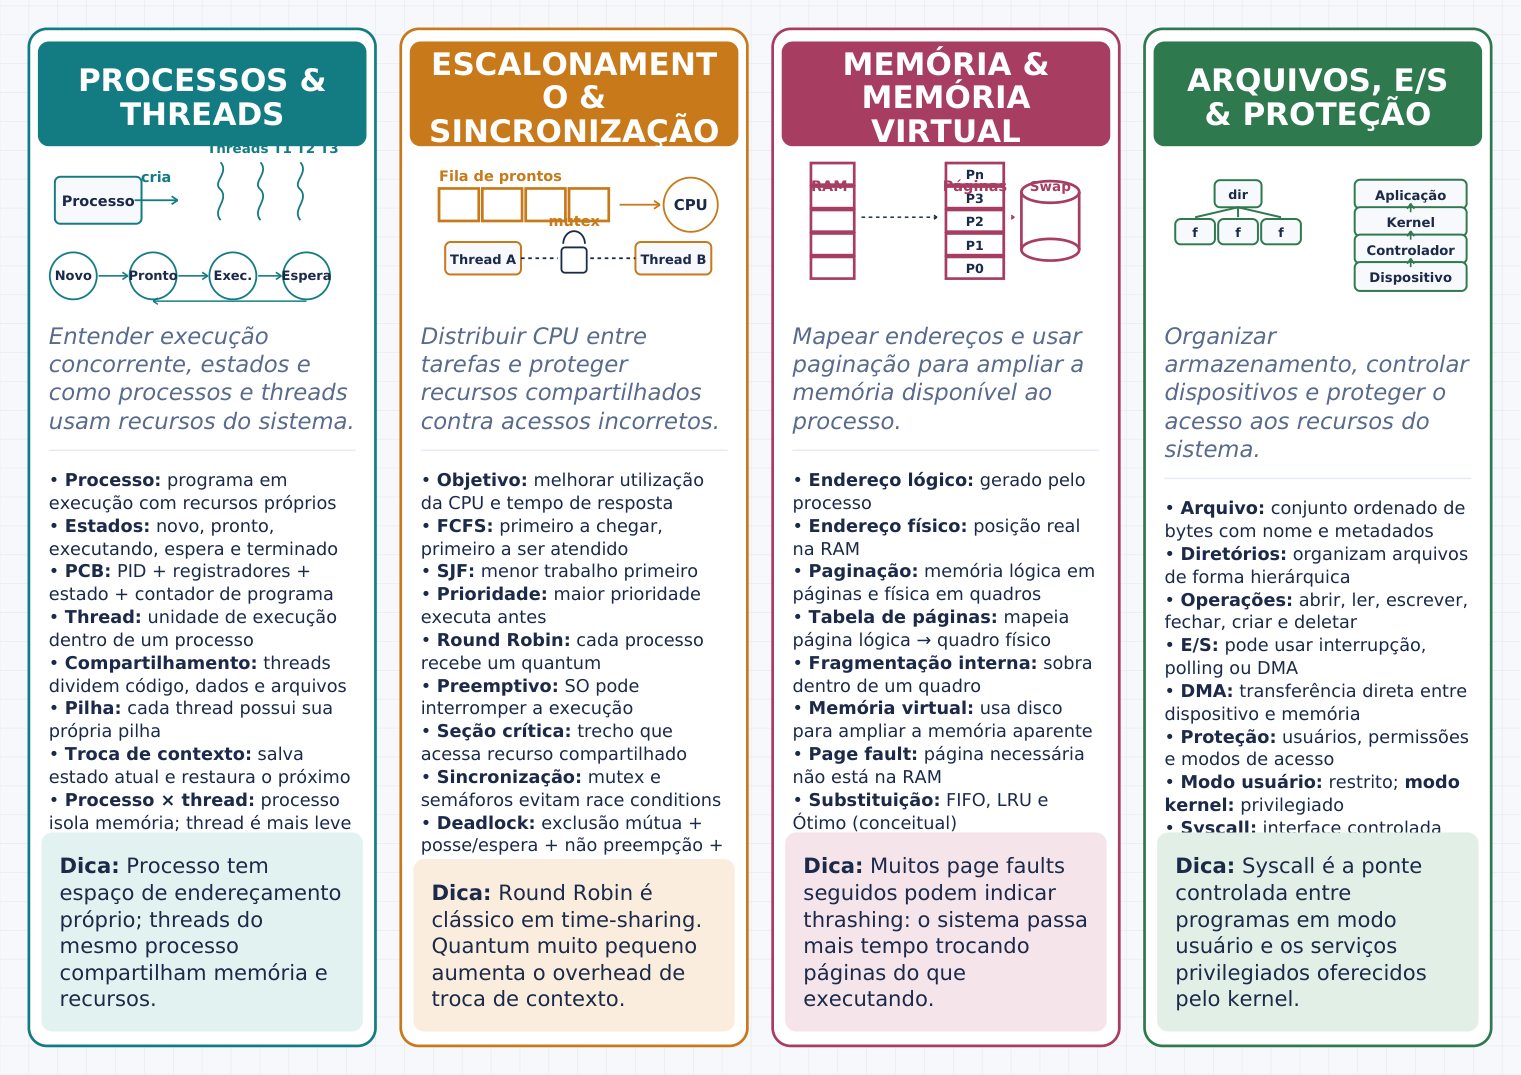

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Sistemas_Operacionais.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) ESCALONAMENTO - FCFS, SJF e Round Robin
   FCFS     -> turnarround medio = 6.00  | [(1, 0, 6), (2, 6, 14), (3, 14, 21), (4, 21, 24)]
   SJF      -> turnarround medio = 6.00  | [(4, 0, 3), (1, 3, 9), (3, 9, 16), (2, 16, 24)]
   RR(q=2)  -> turnarround medio = 1.50  | [(4, 14, 15), (1, 15, 17), (2, 21, 23), (3, 23, 24)]

2) DIAGRAMA DE GANTT - Round Robin


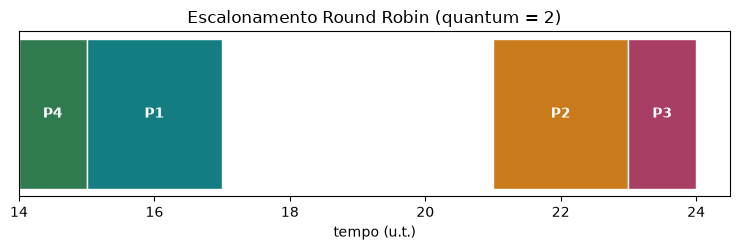


3) SINCRONIZACAO: incremento sem e com lock


   sem lock: esperado 1600000, obtido 1600000  -> RACE CONDITION


   com lock: esperado 1600000, obtido 1600000  -> OK

4) MEMORIA VIRTUAL - substituicao de paginas FIFO vs LRU
   FIFO: 13 page faults | LRU: 12 page faults (3 molduras, sequencia de referencia classica)

5) PROCESSO vs THREAD
   Processo: espaco de endereco proprio, isolado, custo maior de criacao.
   Thread:   compartilha memoria do processo, leve, precisa de sincronizacao.

6) DEADLOCK: espera circular
   P1 segura A e quer B | P2 segura B e quer A  -> deadlock (evite com ordem global)

OK - sistema operacional simulado em Python.


In [3]:

%matplotlib inline
import threading
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("1) ESCALONAMENTO - FCFS, SJF e Round Robin")
processos = [(1, 6), (2, 8), (3, 7), (4, 3)]  # (id, duracao)
def fcfs(p):
    t, saida = 0, []
    for pid, d in sorted(p):
        saida.append((pid, t, t + d)); t += d
    return saida
def sjf(p):
    t, saida, resto = 0, [], sorted(p, key=lambda x: x[1])
    for pid, d in resto:
        saida.append((pid, t, t + d)); t += d
    return saida
def rr(p, quantum=2):
    fila = list(p); t, saida, resto = 0, [], {}
    while fila:
        pid, d = fila.pop(0)
        executa = min(d, quantum)
        inicio = t; t += executa
        d -= executa
        if d > 0: fila.append((pid, d))
        else: saida.append((pid, inicio, t))
    return saida

def tempo_medio(saida):
    return sum(fim - t0 for _, t0, fim in saida)/len(saida)

for nome, fun in (("FCFS", fcfs), ("SJF", sjf), ("RR(q=2)", rr)):
    s = fun(processos)
    print(f"   {nome:<8} -> turnarround medio = {tempo_medio(s):.2f}  | {s}")

print("\n2) DIAGRAMA DE GANTT - Round Robin")
gantt = rr(processos)
fig, ax = plt.subplots(figsize=(7.5, 2.6))
cores = ["#147D82", "#C97A1A", "#A83E63", "#2F7A4F"]
for pid, t0, t1 in gantt:
    ax.barh(0, t1 - t0, left=t0, height=0.5, color=cores[pid-1], edgecolor="white")
    ax.text((t0 + t1)/2, 0, f"P{pid}", ha="center", va="center", color="white", fontweight="bold")
ax.set_yticks([]); ax.set_xlabel("tempo (u.t.)")
ax.set_title("Escalonamento Round Robin (quantum = 2)")
plt.tight_layout(); plt.show()

print("\n3) SINCRONIZACAO: incremento sem e com lock")
cont = [0]
def sem_lock(n=200000):
    for _ in range(n): cont[0] += 1
def com_lock(lk, n=200000):
    for _ in range(n):
        with lk: cont[0] += 1
ths = [threading.Thread(target=sem_lock) for _ in range(8)]
for t in ths: t.start()
for t in ths: t.join()
print(f"   sem lock: esperado 1600000, obtido {cont[0]}  -> RACE CONDITION")

cont[0] = 0
lk = threading.Lock()
ths = [threading.Thread(target=com_lock, args=(lk,)) for _ in range(8)]
for t in ths: t.start()
for t in ths: t.join()
print(f"   com lock: esperado 1600000, obtido {cont[0]}  -> OK")

print("\n4) MEMORIA VIRTUAL - substituicao de paginas FIFO vs LRU")
refs = [7, 0, 1, 2, 0, 3, 0, 4, 2, 3, 0, 3, 2, 1, 2, 0, 1, 7]
def fifo(refs, frames=3):
    mem, faltas = [], 0
    for r in refs:
        if r not in mem:
            faltas += 1
            if len(mem) == frames: mem.pop(0)
            mem.append(r)
    return faltas
def lru(refs, frames=3):
    mem, faltas = [], 0
    for r in refs:
        if r in mem:
            mem.remove(r); mem.append(r)
        else:
            faltas += 1
            if len(mem) == frames: mem.pop(0)
            mem.append(r)
    return faltas
print(f"   FIFO: {fifo(refs)} page faults | LRU: {lru(refs)} page faults "
      f"(3 molduras, sequencia de referencia classica)")

print("\n5) PROCESSO vs THREAD")
print("   Processo: espaco de endereco proprio, isolado, custo maior de criacao.")
print("   Thread:   compartilha memoria do processo, leve, precisa de sincronizacao.")

print("\n6) DEADLOCK: espera circular")
print("   P1 segura A e quer B | P2 segura B e quer A  -> deadlock (evite com ordem global)")

print("\nOK - sistema operacional simulado em Python.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
